<a href="https://colab.research.google.com/github/demonriot/GenAI/blob/main/GenAI_CCE_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP Training

In [ ]:
# MLP for MNIST
# 784 -> 16 -> 16 -> 10

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.optim as optim

In [ ]:
train_dataset = torchvision.datasets.MNIST(root='./data',
                                           train=True,
                                           transform=transforms.ToTensor(),
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='./data',
                                          train=False,
                                          transform=transforms.ToTensor(),
                                          download = True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.55MB/s]


In [ ]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=100,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=100,
                                          shuffle=False)

In [ ]:
class MLP1(nn.Module):
  def __init__(self):
    super(MLP1, self).__init__()
    self.fc1 = nn.Linear(784, 16)
    self.fc2 = nn.Linear(16, 16)
    self.fc3 = nn.Linear(16, 10)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = x.view(-1, 784)
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x # logits

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

model = MLP1().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=1e-3)
epochs = 10

Using cuda device


In [ ]:
def training_loop(dataloader,model,loss_fn,optimizer):
  size = len(dataloader.dataset) # Number of examples in the dataset
  model.train() # Set the model to training mode
  for batch,(X,y) in enumerate(dataloader):
    X = X.to(device)
    y = y.to(device)
    pred = model(X) # Prediction
    loss = loss_fn(pred,y) # Loss Computation

    loss.backward() # Gradient Computaion
    optimizer.step() # Weight Update

    optimizer.zero_grad() # Gradient Reset

    if batch % 100 == 0:
      loss = loss.item()
      current = batch * len(X)
      print(f"loss : {loss:>7f} [{current:>5d}/{size:>5d}]")


def test_loop(dataloader,model,loss_fn):
  size = len(dataloader.dataset) # number of examples in dataset
  num_batches = len(dataloader) # number of batchs in the loader
  test_loss,correct = 0,0

  with torch.no_grad():
    model.eval() # Inference mode
    for X,y in dataloader:
      X = X.to(device)
      y = y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred,y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size

  print(f"Test Error : Accuracy {correct * 100}, Avg Loss {test_loss} ")


In [ ]:
print(f"Model Structure : {model}\n\n")

for name,param in model.named_parameters():
  print(f"Layer : {name} | Size : {param.size()} | Values : {param[:2]}\n")

Model Structure : MLP1(
  (fc1): Linear(in_features=784, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=10, bias=True)
  (relu): ReLU()
)


Layer : fc1.weight | Size : torch.Size([16, 784]) | Values : tensor([[-0.0340, -0.0025,  0.0207,  ..., -0.0034,  0.0258,  0.0239],
        [-0.0197, -0.0245,  0.0294,  ..., -0.0173,  0.0039,  0.0052]],
       device='cuda:0', grad_fn=<SliceBackward0>)

Layer : fc1.bias | Size : torch.Size([16]) | Values : tensor([-0.0147,  0.0243], device='cuda:0', grad_fn=<SliceBackward0>)

Layer : fc2.weight | Size : torch.Size([16, 16]) | Values : tensor([[-0.0282,  0.2279,  0.0224,  0.2421,  0.0924, -0.0267, -0.0534,  0.1321,
         -0.1767, -0.1587, -0.0984, -0.2074, -0.1540, -0.0410, -0.2361, -0.0910],
        [ 0.1740, -0.2359,  0.0384, -0.0226, -0.0791, -0.2123, -0.0783,  0.0363,
         -0.1873,  0.1776, -0.0302, -0.1762, -0.2467, -0.0522,  0.0069, -0.1978]],
       de

In [ ]:
for e in range(epochs):
  print(f"Epoch {e+1}\n-------------------------------")
  training_loop(train_loader,model,loss_fn,optimizer)
  test_loop(test_loader,model,loss_fn)

print("Done Training")

Epoch 1
-------------------------------
loss : 2.319013 [    0/60000]
loss : 1.047827 [10000/60000]
loss : 0.707853 [20000/60000]
loss : 0.414539 [30000/60000]
loss : 0.343990 [40000/60000]
loss : 0.218661 [50000/60000]
Test Error : Accuracy 90.13, Avg Loss 0.34426315780729055 
Epoch 2
-------------------------------
loss : 0.270131 [    0/60000]
loss : 0.354737 [10000/60000]
loss : 0.380498 [20000/60000]
loss : 0.260554 [30000/60000]
loss : 0.356689 [40000/60000]
loss : 0.453912 [50000/60000]
Test Error : Accuracy 92.06, Avg Loss 0.2790604071877897 
Epoch 3
-------------------------------
loss : 0.279252 [    0/60000]
loss : 0.360032 [10000/60000]
loss : 0.306684 [20000/60000]
loss : 0.213719 [30000/60000]
loss : 0.365542 [40000/60000]
loss : 0.175680 [50000/60000]
Test Error : Accuracy 92.49000000000001, Avg Loss 0.2577157783694565 
Epoch 4
-------------------------------
loss : 0.304643 [    0/60000]
loss : 0.306405 [10000/60000]
loss : 0.270083 [20000/60000]
loss : 0.273880 [30000/

In [ ]:
print(f"Model Structure : {model}\n\n")

for name,param in model.named_parameters():
  print(f"Layer : {name} | Size : {param.size()} | Values : {param[:2]}\n")

Model Structure : MLP1(
  (fc1): Linear(in_features=784, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=10, bias=True)
  (relu): ReLU()
)


Layer : fc1.weight | Size : torch.Size([16, 784]) | Values : tensor([[-0.0340, -0.0025,  0.0207,  ..., -0.0034,  0.0258,  0.0239],
        [-0.0197, -0.0245,  0.0294,  ..., -0.0173,  0.0039,  0.0052]],
       device='cuda:0', grad_fn=<SliceBackward0>)

Layer : fc1.bias | Size : torch.Size([16]) | Values : tensor([0.0984, 0.2373], device='cuda:0', grad_fn=<SliceBackward0>)

Layer : fc2.weight | Size : torch.Size([16, 16]) | Values : tensor([[ 0.0793,  0.6047,  0.1556,  0.5942,  0.5094,  0.1186,  0.0345,  0.2187,
         -0.4051, -0.7303, -0.0917, -0.4365, -0.0337, -0.1920, -0.2287,  0.0144],
        [ 0.0955, -0.2559, -0.0442, -0.0464, -0.0791, -0.2123, -0.0962, -0.0300,
         -0.2104,  0.0971, -0.0302, -0.2553, -0.2691, -0.1371,  0.0069, -0.2779]],
       devi

# Training a Conditional GAN

In [ ]:
import torch

import torch.nn as nn

import torch.optim as optim

from torchvision import datasets, transforms

from torchvision.utils import save_image, make_grid

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

import numpy as np

import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
# Size of the random noise vector z

latent_dim = 100

# Number of digit classes in MNIST: 0 to 9

num_classes = 10

# MNIST image size is 28 x 28

img_size = 28

# Total number of pixels in one MNIST image

img_dim = img_size * img_size

# Batch size

batch_size = 128

# Number of training epochs

epochs = 50

# Learning rate

lr = 0.0002

# Adam optimizer beta values

beta1 = 0.5

beta2 = 0.999

# Folder to save generated images

os.makedirs("generated_images", exist_ok=True)

# Folder to save trained models

os.makedirs("saved_models", exist_ok=True)

In [ ]:
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))

])

mnist_dataset = datasets.MNIST(

    root="./data",

    train=True,

    transform=transform,

    download=True

)

dataloader = DataLoader(

    mnist_dataset,

    batch_size=batch_size,

    shuffle=True

)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 471kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.97MB/s]


In [ ]:
class Generator(nn.Module):

    def __init__(self, latent_dim, num_classes, img_dim):

        super(Generator, self).__init__()

        # Embedding layer converts class labels into dense vectors.

        # Example:

        # label 3 -> vector representation of size 10

        self.label_embedding = nn.Embedding(num_classes, num_classes)

        # The input to the generator is:

        # noise vector + label embedding

        input_dim = latent_dim + num_classes

        # Generator network

        self.model = nn.Sequential(

            # First fully connected layer

            nn.Linear(input_dim, 256),

            nn.LeakyReLU(0.2, inplace=True),

            # Second layer

            nn.Linear(256, 512),

            nn.BatchNorm1d(512),

            nn.LeakyReLU(0.2, inplace=True),

            # Third layer

            nn.Linear(512, 1024),

            nn.BatchNorm1d(1024),

            nn.LeakyReLU(0.2, inplace=True),

            # Final layer

            # Output dimension is 784 because MNIST image is 28 x 28

            nn.Linear(1024, img_dim),

            # Tanh maps output to range [-1, 1]

            nn.Tanh()

        )

    def forward(self, noise, labels):

        # Convert labels into embeddings

        label_embed = self.label_embedding(labels)

        # Concatenate noise and label embedding

        gen_input = torch.cat((noise, label_embed), dim=1)

        # Generate flattened image

        img = self.model(gen_input)

        # Reshape image from [batch_size, 784] to [batch_size, 1, 28, 28]

        img = img.view(img.size(0), 1, img_size, img_size)

        return img

In [ ]:
class Discriminator(nn.Module):

    def __init__(self, num_classes, img_dim):

        super(Discriminator, self).__init__()

        # Label embedding

        # Each label is converted into a vector of size num_classes

        self.label_embedding = nn.Embedding(num_classes, num_classes)

        # Discriminator input:

        # flattened image + label embedding

        input_dim = img_dim + num_classes

        self.model = nn.Sequential(

            nn.Linear(input_dim, 512),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),

            nn.LeakyReLU(0.2, inplace=True),

            # Final output is one value:

            # probability of being real

            nn.Linear(256, 1),

            # Sigmoid maps output to [0, 1]

            nn.Sigmoid()

        )

    def forward(self, img, labels):

        # Flatten image from [batch_size, 1, 28, 28] to [batch_size, 784]

        img_flat = img.view(img.size(0), -1)

        # Convert labels into embeddings

        label_embed = self.label_embedding(labels)

        # Concatenate image and label embedding

        d_input = torch.cat((img_flat, label_embed), dim=1)

        # Real/fake probability

        validity = self.model(d_input)

        return validity

In [ ]:
generator = Generator(

    latent_dim=latent_dim,

    num_classes=num_classes,

    img_dim=img_dim

).to(device)

discriminator = Discriminator(

    num_classes=num_classes,

    img_dim=img_dim

).to(device)

print(generator)

print(discriminator)

Generator(
  (label_embedding): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=512, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=1024, out_features=784, bias=True)
    (9): Tanh()
  )
)
Discriminator(
  (label_embedding): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4):

In [ ]:
adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(

    generator.parameters(),

    lr=lr,

    betas=(beta1, beta2)

)

optimizer_D = optim.Adam(

    discriminator.parameters(),

    lr=lr,

    betas=(beta1, beta2)

)

In [ ]:

def save_sample_images(epoch):

    generator.eval()

    with torch.no_grad():

        # Generate one noise vector for each digit class

        z = torch.randn(num_classes, latent_dim).to(device)

        # Labels: 0, 1, 2, ..., 9

        labels = torch.arange(0, num_classes).to(device)

        # Generate images conditioned on these labels

        generated_imgs = generator(z, labels)

        # Convert from [-1, 1] to [0, 1] for visualization

        generated_imgs = (generated_imgs + 1) / 2

        # Save grid image

        save_image(

            generated_imgs,

            f"generated_images/epoch_{epoch}.png",

            nrow=10

        )

    generator.train()

In [ ]:
for epoch in range(1, epochs + 1):

    for batch_idx, (real_imgs, labels) in enumerate(dataloader):

        # Move images and labels to device

        real_imgs = real_imgs.to(device)

        labels = labels.to(device)

        # Current batch size

        current_batch_size = real_imgs.size(0)

        # Create real and fake target labels

        # Real images should be classified as 1

        real_targets = torch.ones(current_batch_size, 1).to(device)

        # Fake images should be classified as 0

        fake_targets = torch.zeros(current_batch_size, 1).to(device)

        # ====================================================

        # Train Generator

        # ====================================================

        optimizer_G.zero_grad()

        # Sample random noise

        z = torch.randn(current_batch_size, latent_dim).to(device)

        # For conditional generation, we need labels.

        # Here we use the same labels from the real batch.

        gen_labels = labels

        # Generate fake images

        gen_imgs = generator(z, gen_labels)

        # Discriminator prediction on generated images

        validity = discriminator(gen_imgs, gen_labels)

        # Generator wants discriminator to think fake images are real.

        # So target is real_targets.

        g_loss = adversarial_loss(validity, real_targets)

        # Backpropagation for generator

        g_loss.backward()

        optimizer_G.step()

        # ====================================================

        # Train Discriminator

        # ====================================================

        optimizer_D.zero_grad()

        # Discriminator loss on real images

        real_pred = discriminator(real_imgs, labels)

        d_real_loss = adversarial_loss(real_pred, real_targets)

        # Discriminator loss on fake images

        # detach() is important:

        # We do not want to update generator while training discriminator.

        fake_pred = discriminator(gen_imgs.detach(), gen_labels)

        d_fake_loss = adversarial_loss(fake_pred, fake_targets)

        # Total discriminator loss

        d_loss = (d_real_loss + d_fake_loss) / 2

        # Backpropagation for discriminator

        d_loss.backward()

        optimizer_D.step()

        # Print progress occasionally

        if batch_idx % 200 == 0:

            print(

                f"Epoch [{epoch}/{epochs}] "

                f"Batch [{batch_idx}/{len(dataloader)}] "

                f"D Loss: {d_loss.item():.4f} "

                f"G Loss: {g_loss.item():.4f}"

            )

    # Save sample images after every epoch

    save_sample_images(epoch)

    print(f"Saved generated sample image for epoch {epoch}")

Epoch [1/50] Batch [0/469] D Loss: 0.6769 G Loss: 0.6758
Epoch [1/50] Batch [200/469] D Loss: 0.7134 G Loss: 0.4957
Epoch [1/50] Batch [400/469] D Loss: 0.5647 G Loss: 1.1464
Saved generated sample image for epoch 1
Epoch [2/50] Batch [0/469] D Loss: 0.5273 G Loss: 0.6099
Epoch [2/50] Batch [200/469] D Loss: 0.5120 G Loss: 1.0450
Epoch [2/50] Batch [400/469] D Loss: 0.6243 G Loss: 0.5682
Saved generated sample image for epoch 2
Epoch [3/50] Batch [0/469] D Loss: 0.6136 G Loss: 1.7717
Epoch [3/50] Batch [200/469] D Loss: 0.6433 G Loss: 0.4805
Epoch [3/50] Batch [400/469] D Loss: 0.4892 G Loss: 1.1288
Saved generated sample image for epoch 3
Epoch [4/50] Batch [0/469] D Loss: 0.6662 G Loss: 0.4537
Epoch [4/50] Batch [200/469] D Loss: 0.5237 G Loss: 0.8206
Epoch [4/50] Batch [400/469] D Loss: 0.5541 G Loss: 0.8815
Saved generated sample image for epoch 4
Epoch [5/50] Batch [0/469] D Loss: 0.7063 G Loss: 0.4390
Epoch [5/50] Batch [200/469] D Loss: 0.5708 G Loss: 0.6082
Epoch [5/50] Batch [

In [ ]:
torch.save(generator.state_dict(), "saved_models/conditional_generator_mnist.pth")

torch.save(discriminator.state_dict(), "saved_models/conditional_discriminator_mnist.pth")

print("Training complete.")

print("Generator saved at: saved_models/conditional_generator_mnist.pth")

Training complete.
Generator saved at: saved_models/conditional_generator_mnist.pth


In [ ]:
def generate_digit(digit, num_images=16):

    """

    Generate images of a specific digit using the trained generator.

    Parameters

    ----------

    digit : int

        Digit to generate. Must be between 0 and 9.

    num_images : int

        Number of images to generate.

    """

    # Safety check

    if digit < 0 or digit > 9:

        raise ValueError("Digit must be between 0 and 9.")

    generator.eval()

    with torch.no_grad():

        # Create random noise

        z = torch.randn(num_images, latent_dim).to(device)

        # Create labels containing the same digit repeated num_images times

        labels = torch.full(

            size=(num_images,),

            fill_value=digit,

            dtype=torch.long

        ).to(device)

        # Generate images

        generated_imgs = generator(z, labels)

        # Convert images from [-1, 1] to [0, 1]

        generated_imgs = (generated_imgs + 1) / 2

        # Make a grid for display

        grid = make_grid(generated_imgs, nrow=4)

        # Convert tensor to numpy image for matplotlib

        np_grid = grid.cpu().numpy()

        # Shape changes from [C, H, W] to [H, W, C]

        np_grid = np.transpose(np_grid, (1, 2, 0))

        # Show the images

        plt.figure(figsize=(6, 6))

        plt.imshow(np_grid.squeeze(), cmap="gray")

        plt.title(f"Generated Digit: {digit}")

        plt.axis("off")

        plt.show()

        # Save generated digit image

        save_path = f"generated_images/generated_digit_{digit}.png"

        save_image(generated_imgs, save_path, nrow=4)

        print(f"Generated image saved at: {save_path}")

    generator.train()

Enter a digit between 0 and 9 to generate: 4


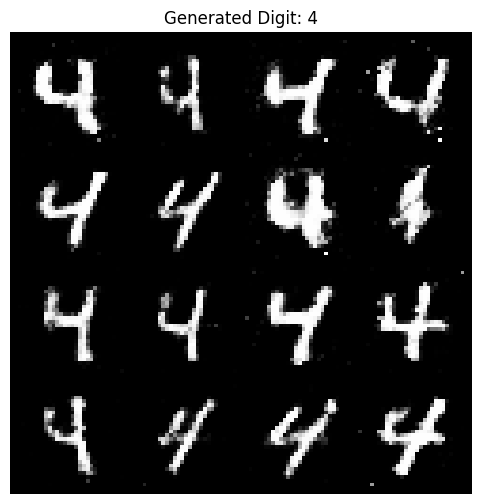

Generated image saved at: generated_images/generated_digit_4.png


In [ ]:
user_input = input("Enter a digit between 0 and 9 to generate: ")

try:

    digit_to_generate = int(user_input)

    generate_digit(

        digit=digit_to_generate,

        num_images=16

    )

except ValueError:

    print("Invalid input. Please enter an integer from 0 to 9.")

# GMMs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from torchvision import datasets

In [ ]:
# Load the MNIST Data

mnist = datasets.MNIST(root='./data', train=True, download=True)

X = mnist.data.numpy()

y = mnist.targets.numpy()

# Convert to float

X = X.astype(np.float32) / 255.0

# Flatten 28x28 -> 784

X = X.reshape(len(X),-1)

print("Dataset Shape",X.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.80MB/s]


Dataset Shape (60000, 784)


In [ ]:
# Reduce the dimension using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=20)

X_pca = pca.fit_transform(X)

print("Reduced Shape of Data ",X_pca.shape)

Reduced Shape of Data  (60000, 20)


In [ ]:
def gaussian_pdf(X, mean, cov):
    """
    Computes Gaussian density.

    Parameters
    ----------
    X      : (N,D)
    mean   : (D,)
    cov    : (D,D)

    Returns
    -------
    pdf : (N,)
    """

    D = X.shape[1]

    cov_inv = np.linalg.inv(cov)

    cov_det = np.linalg.det(cov)

    norm_const = 1.0 / np.sqrt(
        ((2*np.pi)**D) * cov_det
    )

    diff = X - mean

    exponent = -0.5 * np.sum(
        diff @ cov_inv * diff,
        axis=1
    )

    return norm_const * np.exp(exponent)

In [ ]:
def initialize_parameters(X, K):

    N, D = X.shape

    # Randomly choose means
    indices = np.random.choice(N, K, replace=False)

    means = X[indices]

    # Equal mixing probabilities
    weights = np.ones(K) / K

    # Identity covariance
    covariances = np.array([
        np.eye(D)
        for _ in range(K)
    ])

    return weights, means, covariances

In [ ]:
def expectation_step(
        X,
        weights,
        means,
        covariances):

    N = X.shape[0]
    K = len(weights)

    responsibilities = np.zeros((N,K))

    # --------------------------------------------------
    # Compute numerator
    #
    # pi_k * N(x|mu_k,Sigma_k)
    # --------------------------------------------------
    for k in range(K):

        responsibilities[:,k] = (
            weights[k]
            *
            gaussian_pdf(
                X,
                means[k],
                covariances[k]
            )
        )

    # --------------------------------------------------
    # Normalize rows
    #
    # Sum_k r_nk = 1
    # --------------------------------------------------
    responsibilities /= (
        responsibilities.sum(
            axis=1,
            keepdims=True
        ) + 1e-10
    )

    return responsibilities

In [ ]:
def maximization_step(
        X,
        responsibilities):

    N,D = X.shape
    K = responsibilities.shape[1]

    Nk = responsibilities.sum(axis=0)

    # ---------------------------------------
    # Update Mixing Weights
    # ---------------------------------------
    weights = Nk / N

    means = np.zeros((K,D))

    # ---------------------------------------
    # Update Means
    # ---------------------------------------
    for k in range(K):

        means[k] = (
            responsibilities[:,k][:,None]
            * X
        ).sum(axis=0)

        means[k] /= Nk[k]

    # ---------------------------------------
    # Update Covariances
    # ---------------------------------------
    covariances = []

    for k in range(K):

        diff = X - means[k]

        cov = np.zeros((D,D))

        for n in range(N):

            cov += (
                responsibilities[n,k]
                *
                np.outer(
                    diff[n],
                    diff[n]
                )
            )

        cov /= Nk[k]

        cov += 1e-6*np.eye(D)

        covariances.append(cov)

    covariances = np.array(covariances)

    return weights, means, covariances

In [ ]:
def compute_log_likelihood(
        X,
        weights,
        means,
        covariances):

    N = X.shape[0]
    K = len(weights)

    likelihood = np.zeros((N,K))

    for k in range(K):

        likelihood[:,k] = (
            weights[k]
            *
            gaussian_pdf(
                X,
                means[k],
                covariances[k]
            )
        )

    return np.sum(
        np.log(
            likelihood.sum(axis=1)
            + 1e-10
        )
    )

In [ ]:
def fit_gmm(
        X,
        K=10,
        max_iter=20):

    weights, means, covariances = \
        initialize_parameters(X,K)

    for iteration in range(max_iter):

        # ==================================
        # E STEP
        # ==================================
        responsibilities = expectation_step(
            X,
            weights,
            means,
            covariances
        )

        # ==================================
        # M STEP
        # ==================================
        weights, means, covariances = \
            maximization_step(
                X,
                responsibilities
            )

        ll = compute_log_likelihood(
            X,
            weights,
            means,
            covariances
        )

        print(
            f"Iteration {iteration+1:02d}"
            f" | Log-Likelihood = {ll:.2f}"
        )

    return weights, means, covariances

In [ ]:
# Use subset for faster demo

X_train = X_pca[:50000]

weights, means, covariances = fit_gmm(
    X_train,
    K=10,
    max_iter=50
)

Iteration 01 | Log-Likelihood = -1026990.37
Iteration 02 | Log-Likelihood = -1002046.25
Iteration 03 | Log-Likelihood = -994241.86
Iteration 04 | Log-Likelihood = -990399.99
Iteration 05 | Log-Likelihood = -988364.59
Iteration 06 | Log-Likelihood = -987247.17
Iteration 07 | Log-Likelihood = -986596.79
Iteration 08 | Log-Likelihood = -986159.70
Iteration 09 | Log-Likelihood = -985846.72
Iteration 10 | Log-Likelihood = -985583.62
Iteration 11 | Log-Likelihood = -985341.91
Iteration 12 | Log-Likelihood = -985136.18
Iteration 13 | Log-Likelihood = -984970.99
Iteration 14 | Log-Likelihood = -984841.03
Iteration 15 | Log-Likelihood = -984705.98
Iteration 16 | Log-Likelihood = -984555.48
Iteration 17 | Log-Likelihood = -984369.98
Iteration 18 | Log-Likelihood = -984140.79
Iteration 19 | Log-Likelihood = -983849.47
Iteration 20 | Log-Likelihood = -983405.69
Iteration 21 | Log-Likelihood = -982921.34
Iteration 22 | Log-Likelihood = -982384.01
Iteration 23 | Log-Likelihood = -981986.78
Iteration

In [ ]:
print(sum(weights))

0.2693210736168476


In [ ]:
def sample_gmm(
        weights,
        means,
        covariances,
        n_samples=25):

    K = len(weights)

    samples = []

    for _ in range(n_samples):

        # ---------------------------
        # Choose component
        # ---------------------------
        k = np.random.choice(
            K,
            p=weights
        )

        # ---------------------------
        # Draw Gaussian sample
        # ---------------------------
        sample = np.random.multivariate_normal(
            means[k],
            covariances[k]
        )

        samples.append(sample)

    return np.array(samples)

In [ ]:
generated_pca = sample_gmm(
    weights,
    means,
    covariances,
    n_samples=25
)

generated_images = \
    pca.inverse_transform(
        generated_pca
    )

generated_images = np.clip(
    generated_images,
    0,
    1
)

generated_images = \
    generated_images.reshape(
        -1,
        28,
        28
    )

ValueError: probabilities do not sum to 1

NameError: name 'generated_images' is not defined

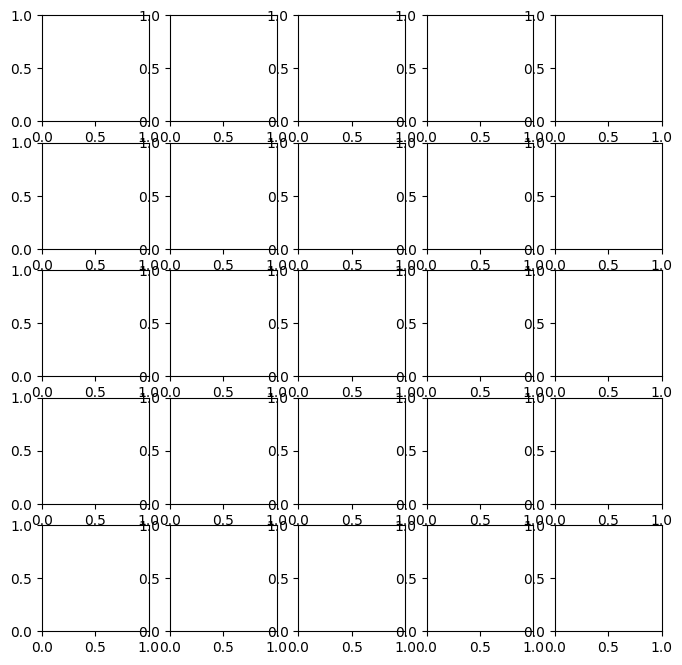

In [ ]:
fig, axes = plt.subplots(
    5,
    5,
    figsize=(8,8)
)

for ax, img in zip(
        axes.ravel(),
        generated_images):

    ax.imshow(
        img,
        cmap='gray'
    )

    ax.axis('off')

plt.suptitle(
    "Digits Generated from Learned GMM"
)

plt.show()

# VAE

In [ ]:
# ============================================================
# Beta-VAE on MNIST using MLP Encoder and Decoder
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os


# ------------------------------------------------------------
# Device setup
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------
batch_size = 128
epochs = 10
learning_rate = 1e-3

input_dim = 28 * 28      # MNIST image flattened size
hidden_dim = 400
latent_dim = 20          # Size of latent vector z

beta_values = [1, 2, 4, 8]   # Different beta values for demo

save_dir = "beta_vae_models"
os.makedirs(save_dir, exist_ok=True)


# ------------------------------------------------------------
# MNIST Dataset
# ------------------------------------------------------------
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


# ============================================================
# Beta-VAE Model
# ============================================================
class BetaVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(BetaVAE, self).__init__()

        # ---------------- Encoder ----------------
        # Input image x -> hidden representation
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Encoder outputs mean and log-variance
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # ---------------- Decoder ----------------
        # Latent vector z -> hidden representation
        self.fc_dec1 = nn.Linear(latent_dim, hidden_dim)

        # Hidden representation -> reconstructed image
        self.fc_dec2 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        """
        Encoder:
        Takes flattened image x and produces mu and logvar.
        """
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick:

        z = mu + std * epsilon

        This allows backpropagation through random sampling.
        """
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        """
        Decoder:
        Takes latent vector z and reconstructs image.
        """
        h = F.relu(self.fc_dec1(z))

        # Sigmoid is used because MNIST pixel values are in [0, 1]
        x_recon = torch.sigmoid(self.fc_dec2(h))
        return x_recon

    def forward(self, x):
        """
        Full VAE forward pass:
        x -> encoder -> mu, logvar -> z -> decoder -> reconstruction
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


# ============================================================
# Loss Function
# ============================================================
def beta_vae_loss(x_recon, x, mu, logvar, beta):
    """
    Beta-VAE loss:

    Total Loss = Reconstruction Loss + beta * KL Divergence

    Reconstruction Loss:
        Measures how close reconstructed image is to original image.

    KL Divergence:
        Forces latent distribution to remain close to standard normal N(0, I).

    Beta:
        Controls strength of KL regularization.
    """

    # Binary cross entropy reconstruction loss
    recon_loss = F.binary_cross_entropy(
        x_recon,
        x,
        reduction="sum"
    )

    # KL divergence between q(z|x) and N(0, I)
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss


# ============================================================
# Training Loop
# ============================================================
def train_model(beta):
    print(f"\nTraining Beta-VAE with beta = {beta}")

    model = BetaVAE(input_dim, hidden_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_recon_loss = 0
        total_kl_loss = 0

        for images, _ in train_loader:
            # Flatten images from [B, 1, 28, 28] to [B, 784]
            images = images.view(images.size(0), -1).to(device)

            # Forward pass
            recon_images, mu, logvar = model(images)

            # Compute loss
            loss, recon_loss, kl_loss = beta_vae_loss(
                recon_images,
                images,
                mu,
                logvar,
                beta
            )

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()

        avg_loss = total_loss / len(train_dataset)
        avg_recon = total_recon_loss / len(train_dataset)
        avg_kl = total_kl_loss / len(train_dataset)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon:.4f} | "
            f"KL: {avg_kl:.4f}"
        )

    # Save model
    model_path = f"{save_dir}/beta_vae_beta_{beta}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved at: {model_path}")


# ============================================================
# Train for multiple beta values
# ============================================================
for beta in beta_values:
    train_model(beta)

Using device: cuda

Training Beta-VAE with beta = 1
Epoch [1/10] Loss: 165.0482 | Recon: 149.8834 | KL: 15.1648
Epoch [2/10] Loss: 121.1678 | Recon: 98.8954 | KL: 22.2724
Epoch [3/10] Loss: 114.2842 | Recon: 90.3181 | KL: 23.9661
Epoch [4/10] Loss: 111.4375 | Recon: 86.9206 | KL: 24.5168
Epoch [5/10] Loss: 109.7347 | Recon: 84.9761 | KL: 24.7587
Epoch [6/10] Loss: 108.6076 | Recon: 83.6875 | KL: 24.9200
Epoch [7/10] Loss: 107.7943 | Recon: 82.7624 | KL: 25.0319
Epoch [8/10] Loss: 107.1265 | Recon: 81.9974 | KL: 25.1291
Epoch [9/10] Loss: 106.6016 | Recon: 81.4366 | KL: 25.1651
Epoch [10/10] Loss: 106.1744 | Recon: 80.9200 | KL: 25.2544
Model saved at: beta_vae_models/beta_vae_beta_1.pth

Training Beta-VAE with beta = 2
Epoch [1/10] Loss: 178.3212 | Recon: 160.3221 | KL: 8.9995
Epoch [2/10] Loss: 141.5909 | Recon: 113.7652 | KL: 13.9129
Epoch [3/10] Loss: 134.9367 | Recon: 104.4361 | KL: 15.2503
Epoch [4/10] Loss: 131.9878 | Recon: 100.2595 | KL: 15.8641
Epoch [5/10] Loss: 130.2161 | Re

Loaded model from: beta_vae_models/beta_vae_beta_8.pth


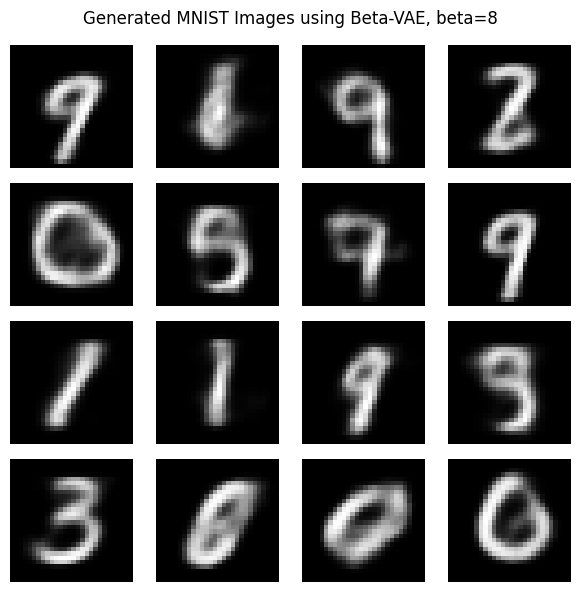

In [ ]:
# ============================================================
# Generate MNIST-like digits using trained Beta-VAE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Device setup
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Same model settings used during training
# ------------------------------------------------------------
input_dim = 28 * 28
hidden_dim = 400
latent_dim = 20

beta = 8   # Choose which trained beta model to load
model_path = f"beta_vae_models/beta_vae_beta_{beta}.pth"


# ============================================================
# Same Beta-VAE model definition
# ============================================================
class BetaVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(BetaVAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc_dec1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_dec2 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        h = F.relu(self.fc_dec1(z))
        x_recon = torch.sigmoid(self.fc_dec2(h))
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


# ------------------------------------------------------------
# Load trained model
# ------------------------------------------------------------
model = BetaVAE(input_dim, hidden_dim, latent_dim).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print(f"Loaded model from: {model_path}")


# ============================================================
# Generate new samples
# ============================================================
num_samples = 16

with torch.no_grad():
    # Sample z from standard normal distribution N(0, I)
    z = torch.randn(num_samples, latent_dim).to(device)

    # Decode z to generate images
    generated_images = model.decode(z)

    # Reshape from [B, 784] to [B, 1, 28, 28]
    generated_images = generated_images.view(num_samples, 1, 28, 28)


# ============================================================
# Display generated images
# ============================================================
plt.figure(figsize=(6, 6))

for i in range(num_samples):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"Generated MNIST Images using Beta-VAE, beta={beta}")
plt.tight_layout()
plt.show()

# CNNs

In [ ]:
# Lenet Demo

# ============================================================
# DEMO 1: LeNet from scratch on MNIST
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Hyperparameters
# -------------------------
batch_size = 128
learning_rate = 1e-3
epochs = 5

# -------------------------
# Data
# -------------------------
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -------------------------
# LeNet model
# -------------------------
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Input: (B, 1, 28, 28)
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5,padding = 2, stride =1),   # -> (B, 6, 28, 28)
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),                     # -> (B, 6, 14, 14)

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),  # -> (B, 16, 10, 10)
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)                      # -> (B, 16, 5, 5)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                              # -> (B, 16*5*5 = 400)
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = LeNet(num_classes=10).to(device)
print(model)

# -------------------------
# Loss and optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# -------------------------
# Train function
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

# -------------------------
# Eval function
# -------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

# -------------------------
# Training loop
# -------------------------
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 63.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.68MB/s]


LeNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)
Epoch [1/5] Train Loss: 0.5066, Train Acc: 0.8447 | Test Loss: 0.1840, Test Acc: 0.9423
Epoch [2/5] Train Loss: 0.1493, Train Acc: 0.9548 | Test Loss: 0.1014, Test Acc: 0.9684
Epoch [3/5] Train Loss: 0.0991, Train Acc: 0.9698 | Test Loss: 0.0754, Test Acc: 0.9741
Epoch [4/5] Train Loss: 0.0749, Train Acc: 0.9769 | Test Loss: 0.0605, Test Acc: 0.9795
Epoch [5/5] Train Loss: 0.0600, Train Acc: 0.98

In [ ]:
# Transfer learning : Alex net

# Load pre trainined weights of Alex net


import torchvision.models as models

weights = models.AlexNet_Weights.DEFAULT
model = models.alexnet(weights=weights)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 188MB/s]


In [ ]:
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
model.classifier[6] = nn.Linear(4096,10)

In [ ]:
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
import torchvision.models as models

weights = models.VGG19_BN_Weights.DEFAULT
model = models.vgg19_bn(weights=weights)

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:05<00:00, 99.5MB/s]


In [ ]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [ ]:
# Load ResNet-18 model

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 64.9MB/s]


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# DDPM - Sample Estimate

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
from tqdm import tqdm

# --- 1. Configuration and Hyperparameters ---
IMG_SIZE = 28
BATCH_SIZE = 128
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
TIMESTEPS = 1000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
# --- 2. U-Net Architecture (Denoising Network) ---

class ConvBlock(nn.Module):
    """
    A basic convolutional block that:
      1) Applies two 3×3 convolutions (with BatchNorm + ReLU)
      2) Injects a time-step embedding as a per-channel bias between them
    """
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        # MLP to project the time embedding into a bias vector of size out_channels
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        # First conv layer: from in_channels to out_channels, 3×3 with padding
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        # Second conv layer: maintains out_channels
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        # BatchNorm layers to stabilize training after each conv
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # ReLU activation function
        self.relu = nn.ReLU()

    def forward(self, x, t_emb):
        # x: [B, in_channels, H, W], t_emb: [B, time_emb_dim]
        # 1) Conv → ReLU → BatchNorm
        h = self.bn1(self.relu(self.conv1(x)))
        # 2) Project time embedding → [B, out_channels]
        time_emb = self.relu(self.time_mlp(t_emb))
        # 3) Reshape to [B, out_channels, 1, 1] so it can broadcast spatially
        time_emb = time_emb[(...,) + (None,) * 2]
        # 4) Add time bias to conv features
        h = h + time_emb
        # 5) Second Conv → ReLU → BatchNorm
        h = self.bn2(self.relu(self.conv2(h)))
        return h


class UNet(nn.Module):
    """
    A U-Net that incorporates time conditioning.  Instead of predicting noise,
    this version directly predicts the clean image x₀.
    """
    def __init__(self, in_channels=1, out_channels=1, time_emb_dim=256):
        super().__init__()
        # MLP to refine the sinusoidal time encoding before feeding into ConvBlocks
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # Encoder (downsampling) path
        self.inc   = ConvBlock(in_channels, 64,  time_emb_dim)  # initial block
        self.down1 = ConvBlock(64,           128, time_emb_dim)
        self.down2 = ConvBlock(128,          256, time_emb_dim)
        self.downsample = nn.MaxPool2d(2)  # half spatial dims

        # Bottleneck: two ConvBlocks at the lowest resolution
        self.bot1 = ConvBlock(256, 256, time_emb_dim)
        self.bot2 = ConvBlock(256, 256, time_emb_dim)

        # Decoder (upsampling) path
        # Each up block concatenates skip connection from the encoder
        self.up1 = ConvBlock(256 + 128, 128, time_emb_dim)
        self.up2 = ConvBlock(128 + 64,   64,  time_emb_dim)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Final 1×1 conv to map back to the desired number of channels (clean image x₀)
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def pos_encoding(self, t, dim):
        """
        Compute sinusoidal embeddings for timesteps t:
          - inv_freq: frequencies for sin/cos
          - pos_emb_sin/cos: [B, dim/2] each → concatenated to [B, dim]
        """
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        inv_freq = inv_freq.to(t.device)
        pos_emb_sin = torch.sin(t.float().unsqueeze(1) * inv_freq)
        pos_emb_cos = torch.cos(t.float().unsqueeze(1) * inv_freq)
        pos_emb = torch.cat([pos_emb_sin, pos_emb_cos], dim=-1)
        return pos_emb

    def forward(self, x, t):
        """
        x: noisy image [B,1,H,W], t: timestep tensor [B]
        Returns the network's estimate of the clean image x₀.
        """
        # 1) Build time embedding: sinusoidal → MLP
        t_emb = self.time_mlp(self.pos_encoding(t, self.time_mlp[0].in_features))

        # --- Encoder ---
        x1 = self.inc(x, t_emb)                   # [B,  64, H, W]
        x2 = self.down1(self.downsample(x1), t_emb)  # [B, 128, H/2, W/2]
        x3 = self.down2(self.downsample(x2), t_emb)  # [B, 256, H/4, W/4]

        # --- Bottleneck ---
        x_bot = self.bot1(x3, t_emb)                # [B, 256, H/4, W/4]
        x_bot = self.bot2(x_bot, t_emb)             # [B, 256, H/4, W/4]

        # --- Decoder ---
        x_up1     = self.upsample(x_bot)            # [B,256,H/2,W/2]
        x_concat1 = torch.cat([x_up1, x2], dim=1)   # skip connection
        x_dec1    = self.up1(x_concat1, t_emb)      # [B,128,H/2,W/2]

        x_up2     = self.upsample(x_dec1)           # [B,128,H,W]
        x_concat2 = torch.cat([x_up2, x1], dim=1)   # skip connection
        x_dec2    = self.up2(x_concat2, t_emb)      # [B, 64, H, W]

        # --- Output: predicted clean image x₀ ---
        predicted_x0 = self.outc(x_dec2)            # [B,1,H,W]
        return predicted_x0

In [ ]:
# --- 3. DDPM Class (modified for x₀ estimation) ---
class DDPM(nn.Module):
    def __init__(self, model, timesteps=1000,
                 beta_start=0.0001, beta_end=0.02,
                 device=DEVICE):
        super().__init__()
        # The U-Net (or other backbone) now predicts x₀ directly
        self.model      = model.to(device)
        # Total diffusion steps
        self.timesteps  = timesteps
        # Device for tensors
        self.device     = device

        # 1) Linear noise schedule β₁…β_T
        self.betas      = torch.linspace(beta_start, beta_end, timesteps).to(device)
        # 2) Signal coefficients α_t = 1 − β_t
        self.alphas     = 1.0 - self.betas
        # 3) Cumulative product ᾱ_t = ∏_{s=1}^t α_s
        self.alphas_cumprod      = torch.cumprod(self.alphas, axis=0)
        # 4) ᾱ_{t-1}, padded so that ᾱ₀ = 1
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # 5) Precompute √ᾱ_t and √(1 − ᾱ_t) for forward sampling
        self.sqrt_alphas_cumprod          = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # 6) Analytical posterior variance Var[q(x_{t-1} | x_t, x₀)]
        self.posterior_variance = (
            self.betas
            * (1. - self.alphas_cumprod_prev)
            / (1. - self.alphas_cumprod)
        )

    def forward_diffusion(self, x_0, t, noise=None):
        """
        q(x_t | x₀): Corrupt x₀ at timestep t by mixing with Gaussian noise.
        Returns:
          x_t   = √ᾱ_t · x₀ + √(1−ᾱ_t) · noise
          noise = the random noise used (needed internally for inference)
        """
        # If no noise provided, draw standard normal
        if noise is None:
            noise = torch.randn_like(x_0)

        # Gather the precomputed scale factors for each sample
        a_bar_t = self.sqrt_alphas_cumprod[t][:, None, None, None]
        b_bar_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]

        # Compute the noisy x_t
        x_t = a_bar_t * x_0 + b_bar_t * noise
        return x_t, noise

    def sample_timesteps(self, batch_size):
        """Uniformly sample timesteps in [0, T) for a batch."""
        return torch.randint(
            0, self.timesteps, (batch_size,),
            device=self.device
        ).long()

    @torch.no_grad()
    def sample(self, num_samples, channels, img_size):
        """
        Reverse the diffusion process to generate new images:
          • Start at x_T ∼ N(0,I)
          • For t = T−1…0:
              – Predict x₀ from xₜ
              – Infer εₜ = (xₜ − √ᾱₜ · x₀_pred) / √(1−ᾱₜ)
              – Compute posterior mean µ = reverse_ddpm_mean(εₜ)
              – Sample x_{t-1} ∼ N(µ, Var)
        """
        self.model.eval()
        # Initialize x_T as pure noise
        x = torch.randn(num_samples, channels, img_size, img_size, device=self.device)

        for i in tqdm(
            reversed(range(self.timesteps)),
            desc="Sampling", total=self.timesteps
        ):
            # Create a tensor of the current timestep
            t = torch.full((num_samples,), i, device=self.device, dtype=torch.long)

            # 1) Predict clean image x₀ from the current xₜ
            predicted_x0 = self.model(x, t)

            # 2) Infer the noise term εₜ by inverting the forward equation:
            #    εₜ = (xₜ − √ᾱₜ·x₀_pred) / √(1−ᾱₜ)
            a_bar_t = self.sqrt_alphas_cumprod[t][:, None, None, None]
            b_bar_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
            predicted_noise = (x - a_bar_t * predicted_x0) / b_bar_t

            # 3) Gather α_t, ᾱ_t, β_t for reverse update
            alpha_t     = self.alphas[t][:, None, None, None]
            alpha_bar_t = self.alphas_cumprod[t][:, None, None, None]
            beta_t      = self.betas[t][:, None, None, None]

            # 4) Compute the reverse DDPM mean using the inferred noise
            mean = (
                1 / torch.sqrt(alpha_t)
            ) * (
                x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
            )

            # 5) Add stochasticity (unless at t=0)
            if i > 0:
                z   = torch.randn_like(x)
                var = self.posterior_variance[t][:, None, None, None]
                x   = mean + torch.sqrt(var) * z
            else:
                x = mean  # final step: deterministic

        # Restore train mode
        self.model.train()

        # Scale outputs from [-1,1] → [0,1] → [0,255] uint8
        x = (x.clamp(-1, 1) + 1) / 2
        x = x.cpu().permute(0, 2, 3, 1).numpy() * 255
        return x.astype(np.uint8)

In [ ]:
# --- 4. Dataset and DataLoader ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

train_dataset = datasets.MNIST(root='./', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.34MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training on cuda:0 with X_0 Estimation


Epoch 1/50:   0%|          | 0/469 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/50: 100%|██████████| 469/469 [00:53<00:00,  8.70it/s]


Epoch 1, Average Loss: 0.2585


Epoch 2/50: 100%|██████████| 469/469 [00:51<00:00,  9.09it/s]


Epoch 2, Average Loss: 0.1556


...

Epoch 8, Average Loss: 0.1495


Epoch 9/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 9, Average Loss: 0.1488


Epoch 10/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


Epoch 10, Average Loss: 0.1489


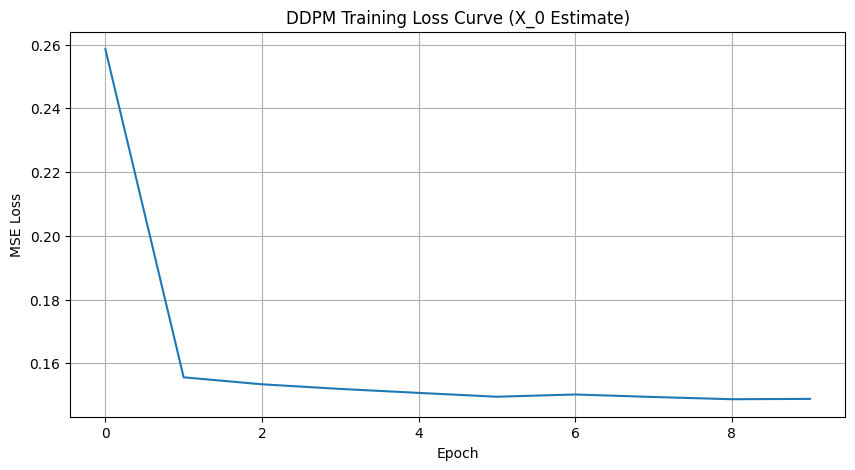

Epoch 11/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


Epoch 11, Average Loss: 0.1494


Epoch 12/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 12, Average Loss: 0.1482


Epoch 13/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


...

Epoch 18, Average Loss: 0.1470


Epoch 19/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


Epoch 19, Average Loss: 0.1472


Epoch 20/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 20, Average Loss: 0.1473


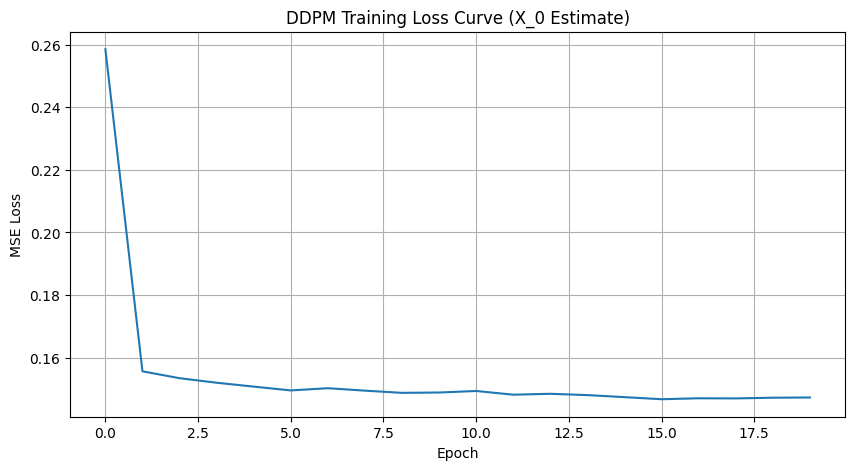

Epoch 21/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


Epoch 21, Average Loss: 0.1462


Epoch 22/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 22, Average Loss: 0.1463


Epoch 23/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


...

Epoch 28, Average Loss: 0.1459


Epoch 29/50: 100%|██████████| 469/469 [00:47<00:00,  9.78it/s]


Epoch 29, Average Loss: 0.1465


Epoch 30/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 30, Average Loss: 0.1464


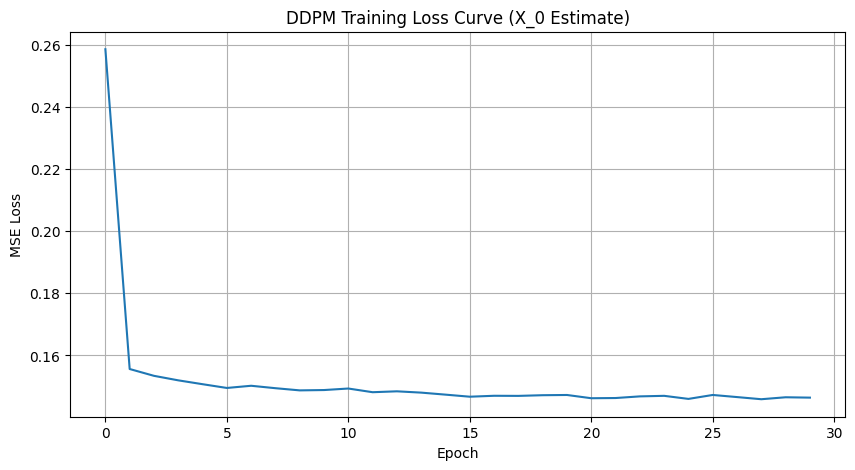

Epoch 31/50: 100%|██████████| 469/469 [00:47<00:00,  9.77it/s]


Epoch 31, Average Loss: 0.1458


Epoch 32/50: 100%|██████████| 469/469 [00:48<00:00,  9.70it/s]


Epoch 32, Average Loss: 0.1453


Epoch 33/50: 100%|██████████| 469/469 [00:48<00:00,  9.72it/s]


...

Epoch 38, Average Loss: 0.1457


Epoch 39/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


Epoch 39, Average Loss: 0.1454


Epoch 40/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 40, Average Loss: 0.1460


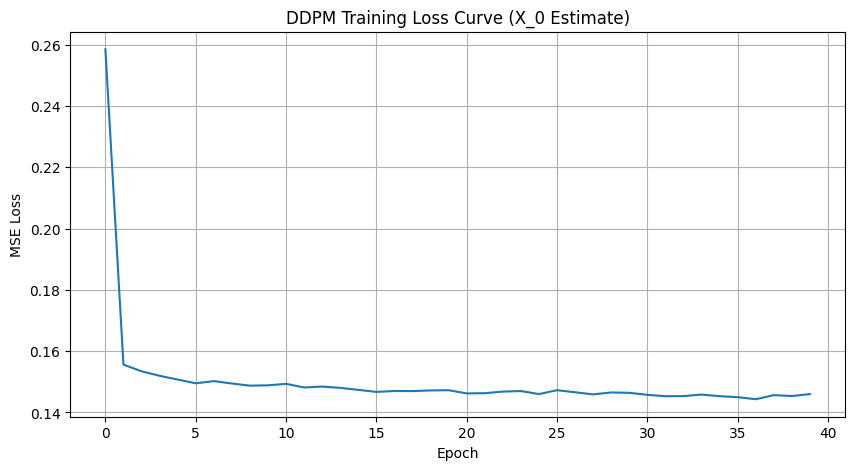

Epoch 41/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 41, Average Loss: 0.1459


Epoch 42/50: 100%|██████████| 469/469 [00:48<00:00,  9.75it/s]


Epoch 42, Average Loss: 0.1451


Epoch 43/50: 100%|██████████| 469/469 [00:48<00:00,  9.77it/s]


...

Epoch 48, Average Loss: 0.1445


Epoch 49/50: 100%|██████████| 469/469 [00:48<00:00,  9.74it/s]


Epoch 49, Average Loss: 0.1439


Epoch 50/50: 100%|██████████| 469/469 [00:47<00:00,  9.78it/s]


Epoch 50, Average Loss: 0.1455


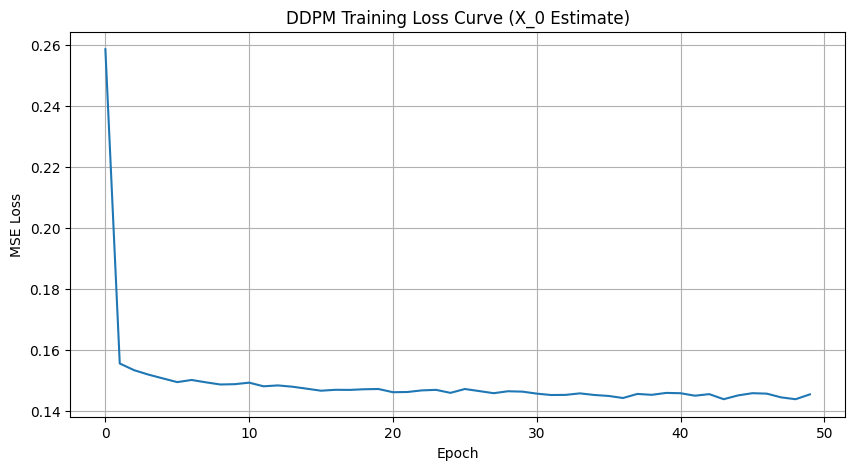

Generating new images (using X_0 estimates for reverse process)...


Sampling: 100%|██████████| 1000/1000 [00:06<00:00, 165.93it/s]


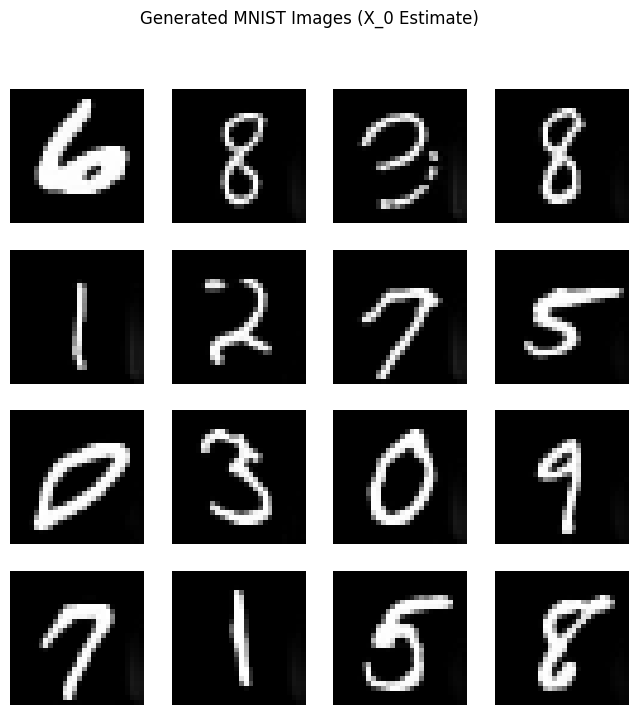

Training and sampling complete!


In [ ]:
# --- 5. Training Loop ---
if __name__ == "__main__":
    unet_model = UNet(in_channels=1, out_channels=1, time_emb_dim=256)
    ddpm = DDPM(unet_model, timesteps=TIMESTEPS, device=DEVICE)
    optimizer = optim.Adam(ddpm.model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss() # Standard MSELoss is used for x_0 prediction

    train_losses = []

    print(f"Training on {DEVICE} with X_0 Estimation")
    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0
        for batch_idx, (images, _) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
            images = images.to(DEVICE) # This is our true x_0

            t = ddpm.sample_timesteps(images.shape[0])

            # Forward diffusion gets us x_t (noisy image)
            x_t, _ = ddpm.forward_diffusion(images, t) # We don't need true_noise for this objective

            # The U-Net predicts the clean image x_0
            predicted_x0 = ddpm.model(x_t, t)

            # The loss is between the predicted x_0 and the true x_0
            loss = criterion(predicted_x0, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_epoch_loss)
        print(f"Epoch {epoch+1}, Average Loss: {avg_epoch_loss:.4f}")

        if (epoch + 1) % 10 == 0 or epoch == NUM_EPOCHS - 1:
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses)
            plt.title("DDPM Training Loss Curve (X_0 Estimate)")
            plt.xlabel("Epoch")
            plt.ylabel("MSE Loss")
            plt.grid(True)
            plt.show()

    print("Generating new images (using X_0 estimates for reverse process)...")
    num_samples_to_generate = 16
    sampled_images = ddpm.sample(num_samples_to_generate, channels=1, img_size=IMG_SIZE)

    plt.figure(figsize=(8, 8))
    for i in range(num_samples_to_generate):
        plt.subplot(int(np.sqrt(num_samples_to_generate)), int(np.sqrt(num_samples_to_generate)), i + 1)
        plt.imshow(sampled_images[i].squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle("Generated MNIST Images (X_0 Estimate)")
    plt.show()

    print("Training and sampling complete!")

# Guided Difussion

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### --- SHARED COMPONENTS (Scheduler & U-Net from previous example) --- ###

def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def forward_diffusion_sample(x_0, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    mean = sqrt_alphas_cumprod_t * x_0
    variance = sqrt_one_minus_alphas_cumprod_t * noise

    return mean + variance, noise

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


In [ ]:
### --- Part 1: Unconditional DDPM (U-Net Model) --- ###
# This is the standard noise-prediction U-Net. It is trained unconditionally,
# meaning it does not use any class labels during its training.

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        h = self.bn1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bn2(self.relu(self.conv2(h)))
        return self.transform(h)

class Unet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 1
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 1
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(time_emb_dim),
                nn.Linear(time_emb_dim, time_emb_dim),
                nn.ReLU()
            )
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], time_emb_dim) for i in range(len(down_channels)-1)])
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True) for i in range(len(up_channels)-1)])
        self.output = nn.Conv2d(up_channels[-1], image_channels, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        x = self.conv0(x)
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        return self.output(x)

# --- End of Part 1 ---
# =====================

In [ ]:
### --- Part 2: Noise-Aware Classifier --- ###
# This is a simple CNN classifier, but with a crucial modification: it takes the
# timestep 't' as an input. It must be trained on noisy images to learn
# how to classify them at any stage of the diffusion process.

class NoisyClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        time_emb_dim = 32

        # Time embedding, similar to the U-Net
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # Standard CNN architecture
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        # The time embedding will be added after this layer
        self.fc1 = nn.Linear(32 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x, time):
        # Embed the timestep
        t_emb = self.time_mlp(time)

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        # Add time embedding to the features
        # We need to process the time embedding to match the feature dimensions
        t_emb_transformed = F.interpolate(t_emb.unsqueeze(-1).unsqueeze(-1), size=x.shape[2:], mode='nearest')

        x = x + t_emb_transformed

        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# --- End of Part 2 ---
# =====================

In [ ]:
### --- Main Execution & Training --- ###
if __name__ == '__main__':
    # Hyperparameters
    IMG_SIZE = 32
    BATCH_SIZE = 128
    TIMESTEPS = 1000

    # --- Prepare Diffusion Constants ---
    betas = linear_beta_schedule(timesteps=TIMESTEPS)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, axis=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

    # --- Load Data ---
    transforms_mnist = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms_mnist)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    # --- Initialize and Train Models ---
    # For a real application, you would save/load these models.
    # Here, we train them from scratch for a self-contained example.

    # 1. Train the Unconditional DDPM
    ddpm_model = Unet().to(device)
    optimizer_ddpm = optim.Adam(ddpm_model.parameters(), lr=0.001)
    criterion_ddpm = nn.MSELoss()
    DDPM_EPOCHS = 15 # Reduced for quicker demonstration

    print("--- Training Unconditional DDPM ---")
    for epoch in range(DDPM_EPOCHS):
        for step, (images, _) in enumerate(tqdm(train_loader, desc=f"DDPM Epoch {epoch+1}")):
            optimizer_ddpm.zero_grad()
            x0 = images.to(device)
            t = torch.randint(0, TIMESTEPS, (x0.shape[0],), device=device).long()
            xt, noise_target = forward_diffusion_sample(x0, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)
            predicted_noise = ddpm_model(xt, t)
            loss = criterion_ddpm(noise_target, predicted_noise)
            loss.backward()
            optimizer_ddpm.step()
        print(f"DDPM Epoch {epoch+1} Loss: {loss.item():.4f}")

    # 2. Train the Noise-Aware Classifier
    classifier_model = NoisyClassifier().to(device)
    optimizer_classifier = optim.Adam(classifier_model.parameters(), lr=0.001)
    criterion_classifier = nn.CrossEntropyLoss()
    CLASSIFIER_EPOCHS = 10 # Reduced for quicker demonstration

    print("\n--- Training Noise-Aware Classifier ---")
    for epoch in range(CLASSIFIER_EPOCHS):
        for step, (images, labels) in enumerate(tqdm(train_loader, desc=f"Classifier Epoch {epoch+1}")):
            optimizer_classifier.zero_grad()
            x0 = images.to(device)
            y = labels.to(device)
            t = torch.randint(0, TIMESTEPS, (x0.shape[0],), device=device).long()

            # Create noisy images to train the classifier on
            xt, _ = forward_diffusion_sample(x0, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)

            # Predict labels from noisy images
            predicted_labels = classifier_model(xt, t)
            loss = criterion_classifier(predicted_labels, y)
            loss.backward()
            optimizer_classifier.step()
        print(f"Classifier Epoch {epoch+1} Loss: {loss.item():.4f}")



In [ ]:
@torch.no_grad()
def guided_sample(target_class, guidance_scale=2.0, num_images=16):
    """
    Part 3: Classifier-Guided Sampling
    Generate `num_images` samples of a given `target_class` by steering
    the DDPM reverse process with gradients from a noise-aware classifier.
    """
    # Log the sampling configuration
    print(f"\n--- Starting Guided Generation for class: {target_class} with scale: {guidance_scale} ---")

    # Put both models into evaluation mode (disable dropout/BatchNorm updates)
    ddpm_model.eval()
    classifier_model.eval()

    # 1) Initialize with pure Gaussian noise: x_T ~ N(0, I)
    img = torch.randn((num_images, 1, IMG_SIZE, IMG_SIZE), device=device)

    # 2) Create a tensor `y` of the target class for all images
    y = torch.full((num_images,), target_class, device=device, dtype=torch.long)

    # 3) Iterate timesteps from T-1 down to 0
    for i in tqdm(reversed(range(0, TIMESTEPS)), desc="Guided Sampling", total=TIMESTEPS):
        # a) Prepare a tensor of the current timestep index
        t = torch.full((num_images,), i, device=device, dtype=torch.long)

        # --- Step 1: Unconditional DDPM prediction ---
        # Predict noise ε_θ(x_t, t) without gradient tracking
        with torch.no_grad():
            predicted_noise = ddpm_model(img, t)  # ε_pred shape: [B, C, H, W]

        # Retrieve schedule scalars for this timestep:
        #   β_t
        betas_t = get_index_from_list(betas, t, img.shape)
        #   √(1 − ᾱ_t)
        sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, img.shape)
        #   1 / √(α_t)
        sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, img.shape)

        # Compute the unconditional reverse mean:
        # μ_uncond = (1/√α_t) * ( x_t − (β_t / √(1−ᾱ_t)) * ε_pred )
        unconditional_mean = sqrt_recip_alphas_t * (
            img - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
        )

        # --- Step 2: Compute classifier gradient for guidance ---
        # We enable gradients on `img` to get ∇_{x_t} log p(y | x_t)
        with torch.enable_grad():
            img_with_grad = img.detach().requires_grad_(True)
            logits = classifier_model(img_with_grad, t)          # shape: [B, num_classes]
            log_probs = F.log_softmax(logits, dim=-1)            # log p_φ(y|x_t)
            selected_log_probs = log_probs[torch.arange(num_images), y]
            # classifier_grad = ∂/∂x_t ∑ log p_φ(y|x_t)
            classifier_grad = torch.autograd.grad(
                selected_log_probs.sum(), img_with_grad
            )[0]  # same shape as img: [B, C, H, W]

        # --- Step 3: Combine means with guidance nudge ---
        # Retrieve posterior variance Var[x_{t-1} | x_t]
        posterior_variance_t = get_index_from_list(posterior_variance, t, img.shape)
        # guidance_nudge = guidance_scale * variance * ∇ log p_φ(y|x_t)
        guidance_nudge = guidance_scale * posterior_variance_t * classifier_grad

        # μ_guided = μ_uncond + guidance_nudge
        guided_mean = unconditional_mean + guidance_nudge

        # --- Step 4: Sample the next image x_{t-1} ---
        if i == 0:
            # At final step, no additional noise
            img = guided_mean
        else:
            # Inject Gaussian noise: x_{t-1} = μ_guided + √variance * z
            noise = torch.randn_like(img)
            img = guided_mean + torch.sqrt(posterior_variance_t) * noise

    # Return models to training mode
    ddpm_model.train()
    classifier_model.train()

    # 5) Map pixel range from [-1, 1] back to [0, 1]
    img = (img + 1) * 0.5
    img = img.clamp(0, 1)
    return img

# --- Generate and Plot Images ---
target_digit = 9 # Change this to generate a different digit
generated_images = guided_sample(target_class=target_digit, guidance_scale=2.0)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated_images[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Digit '{target_digit}' using Classifier Guidance")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()